In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("C://Users//lokes//OneDrive//Desktop//Neural_Network//multiclass.csv")

In [3]:
df.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
0,3,12669,9656,7561,214,2674,1338,2
1,3,7057,9810,9568,1762,3293,1776,2
2,3,6353,8808,7684,2405,3516,7844,2
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1


In [4]:
Y = df['class']

In [5]:
df.shape

(440, 8)

In [6]:
df['class'].unique()

array([2, 1, 3])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Region            440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
 7   class             440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [8]:
df.isna().sum()

Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
class               0
dtype: int64

In [9]:
pd.get_dummies(df['Region'])

,1,2,3
0,False,False,True
1,False,False,True
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
435,False,False,True
436,False,False,True
437,False,False,True
438,False,False,True


In [10]:
df = pd.get_dummies(df, columns=['Region'], dtype=int)
df = pd.get_dummies(df, columns=['class'], dtype=int)

In [11]:
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region_1,Region_2,Region_3,class_1,class_2,class_3
0,12669,9656,7561,214,2674,1338,0,0,1,0,1,0
1,7057,9810,9568,1762,3293,1776,0,0,1,0,1,0
2,6353,8808,7684,2405,3516,7844,0,0,1,0,1,0
3,13265,1196,4221,6404,507,1788,0,0,1,1,0,0
4,22615,5410,7198,3915,1777,5185,0,0,1,1,0,0


In [12]:
X = df.drop(columns=['class_1', 'class_2','class_3'], axis=1)
y = df[['class_1', 'class_2','class_3']]

In [13]:
from sklearn.decomposition import PCA

In [14]:
pca = PCA(n_components=2)
visual = pca.fit_transform(X)

In [15]:
visual.shape

(440, 2)

In [16]:
df2 = pd.DataFrame(visual, columns=['F1','F2'])

In [17]:
df2['y'] = Y

In [18]:
df2.head()

,F1,F2,y
0,650.022123,1585.519090,2
1,-4426.804978,4042.451509,2
2,-4841.998706,2578.762176,2
3,990.346438,-6279.805997,1
4,10657.998732,-2159.725815,1


In [19]:
plt.rcParams['figure.figsize']=[6,4]

<Axes: xlabel='F1', ylabel='F2'>

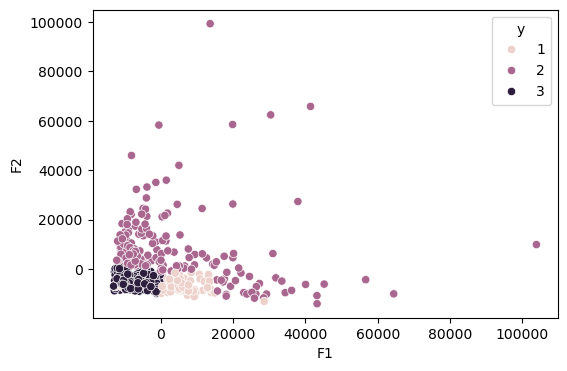

In [20]:
sns.scatterplot(data=df2, x='F1', y='F2', hue='y')

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X,X_test,Y,y_test = train_test_split(X,y, test_size=0.1, random_state=42)

In [23]:
X_train, X_val, y_train, y_val = train_test_split(X,Y, test_size=0.1, random_state=42)

In [24]:
print( len(X_train), len(X_val), len(X_test))

356 40 44


In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [26]:
sc = StandardScaler()

In [27]:
X_train = sc.fit_transform(X_train)

In [28]:
X_val = sc.fit_transform(X_val)

In [29]:
X_test = sc.fit_transform(X_test)

In [30]:
import tensorflow
import keras

In [31]:
from keras import Sequential
from keras.layers import Dense

In [56]:
def create_baseline():
    model = Sequential(
        [
            Dense(32, activation='relu', kernel_initializer='glorot_uniform', input_shape=(9,)),
            Dense(64, activation='relu', kernel_initializer='glorot_uniform'),
            Dense(128, activation='relu', kernel_initializer='glorot_uniform'),
            Dense(64, activation='relu', kernel_initializer='glorot_uniform'),
            Dense(32, activation='relu', kernel_initializer='glorot_uniform'),
            Dense(3, activation='softmax')
        ]
    )
    return model

# Stochasic Gradient Descent

In [37]:
model_1 = create_baseline()

In [38]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,187 (82.76 KB)

 Trainable params: 21,187 (82.76 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model_1.compile(
    optimizer = keras.optimizers.SGD(),
    loss = keras.losses.CategoricalCrossentropy()
)

In [43]:
history = model_1.fit(X_train, y_train, epochs=10, batch_size=50, validation_data=(X_val,y_val))

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 1.0714 - val_loss: 1.0307
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0535 - val_loss: 1.0081
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0351 - val_loss: 0.9923
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0224 - val_loss: 0.9755
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0096 - val_loss: 0.9634
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9990 - val_loss: 0.9516
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9888 - val_loss: 0.9406
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9790 - val_loss: 0.9303
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9693 - val_loss: 0.9194
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9597 - val_loss: 0.9108


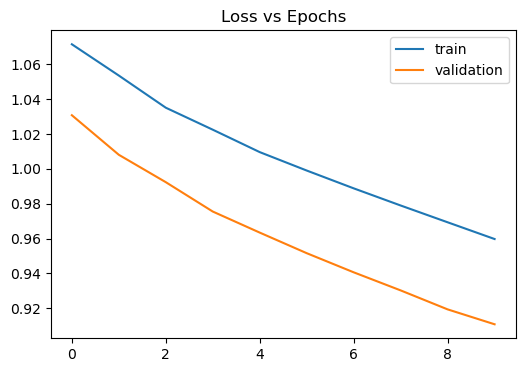

In [44]:
epochs = history.epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, label='train')
plt.plot(epochs, val_loss, label='validation')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()

# Stochastic Gradient Descent with Momentum

In [57]:
model_2 = create_baseline()

C:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,187 (82.76 KB)

 Trainable params: 21,187 (82.76 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model_2.compile(
    optimizer = keras.optimizers.SGD(momentum=0.9),
    loss = keras.losses.CategoricalCrossentropy()
)

In [60]:
history = model_2.fit(X_train, y_train, epochs=50, batch_size=50, validation_data=(X_val,y_val))

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 1.0806 - val_loss: 1.0549
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.0433 - val_loss: 0.9977
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.9988 - val_loss: 0.9363
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.9448 - val_loss: 0.8695
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8826 - val_loss: 0.7849
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8009 - val_loss: 0.6927
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7065 - val_loss: 0.6125
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6192 - val_loss: 0.5351
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5372 - val_loss: 0.4799
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4833 - val_loss: 0.4479
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4352 - val_loss: 0.4256
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3893 - val_loss: 0.3963
E

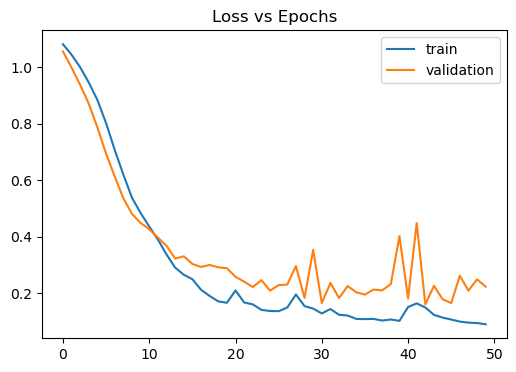

In [61]:
epochs = history.epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, label='train')
plt.plot(epochs, val_loss, label='validation')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()

In [62]:
model_3 = create_baseline()

C:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
model_3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,187 (82.76 KB)

 Trainable params: 21,187 (82.76 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
model_3.compile(
    optimizer = keras.optimizers.RMSprop(rho=0.9),
    loss = keras.losses.CategoricalCrossentropy()
)

In [65]:
history = model_3.fit(X_train, y_train, epochs=50, batch_size=50, validation_data=(X_val,y_val))

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 1.0202 - val_loss: 0.8806
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7703 - val_loss: 0.6597
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5592 - val_loss: 0.4859
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4301 - val_loss: 0.4485
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3585 - val_loss: 0.3581
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3006 - val_loss: 0.3850
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2692 - val_loss: 0.3175
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2762 - val_loss: 0.3072
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2354 - val_loss: 0.3945
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2391 - val_loss: 0.3473
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2113 - val_loss: 0.3055
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1966 - val_loss: 0.2689
E

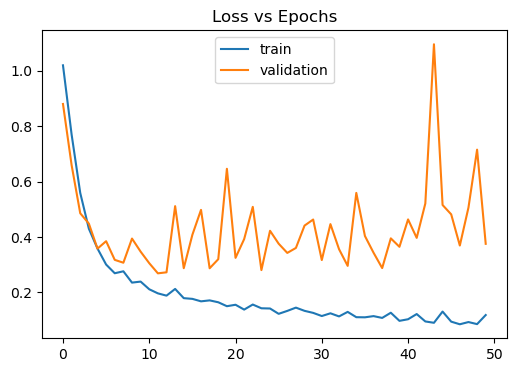

In [66]:
epochs = history.epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, label='train')
plt.plot(epochs, val_loss, label='validation')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()

In [68]:
model_4 = create_baseline()

In [72]:
model_4.compile(optimizer = keras.optimizers.Adam(beta_1= 0.9, beta_2= 0.999),
                loss = keras.losses.CategoricalCrossentropy())

history = model_4.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - loss: 1.1202 - val_loss: 1.0789
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1.0588 - val_loss: 1.0180
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 1.0100 - val_loss: 0.9549
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.9623 - val_loss: 0.8878
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.9094 - val_loss: 0.8181
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.8506 - val_loss: 0.7415
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.7832 - val_loss: 0.6613
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.7120 - val_loss: 0.5806
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.6375 - val_loss: 0.5067
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.5673 - val_loss: 0.4477
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.5105 - val_loss: 0.4023
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.4629 - val_loss: 0.3676


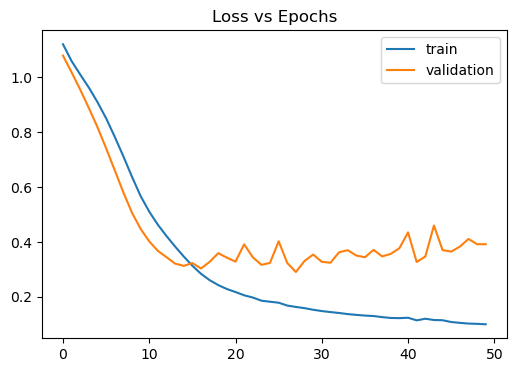

In [73]:
epochs = history.epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, label='train')
plt.plot(epochs, val_loss, label='validation')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()

In [74]:
from keras.callbacks import LearningRateScheduler

In [76]:
def schedule(epoch, lr):
    r0 = 0.01
    lr = (1/(1+r0*epoch))*lr
    return lr

In [77]:
Learning_rate_decay = LearningRateScheduler(schedule)

In [79]:
model_5 = create_baseline()

In [81]:
model_5.compile(
    optimizer=keras.optimizers.Adam(beta_1=0.9, beta_2=0.999),
    loss = keras.losses.CategoricalCrossentropy
)

In [83]:
history = model_5.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128,callbacks=[leraning_rate_decay])

NameError: name 'leraning_rate_decay' is not defined